**spaces**: https://huggingface.co/spaces/thu-sail-lab/Time_RCD/tree/main

**repo**: https://huggingface.co/thu-sail-lab/Time-RCD

# Loading

In [2]:
!pip install wget

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9711 sha256=db28c5444e6d0213cfb6d7c71d27a404709b286d316f3e7bd24e545b5a495851
  Stored in directory: c:\users\oleg\appdata\local\pip\cache\wheels\8b\f1\7f\5c94f0a7a505ca1c81cd1d9208ae2064675d97582078e6c769
Successfully built wget


**Скачать репо:** https://anonymous.4open.science/r/TimeRCD-5BE1

Скачать данные TSB-AD-U (univariate) и TSB-AD-M (multivariate):
* datasets/TSB-AD-U.zip" "https://www.thedatum.org/datasets/TSB-AD-U.zip
* datasets/TSB-AD-M.zip" "https://www.thedatum.org/datasets/TSB-AD-M.zip

Закинул в папку `data/Time-RCD`

In [6]:
import pandas as pd

example = pd.read_csv("../data/Time-RCD/TSB-AD-M/001_Genesis_id_1_Sensor_tr_4055_1st_15538.csv")
example

,MotorData.ActCurrent,MotorData.ActPosition,MotorData.ActSpeed,MotorData.IsAcceleration,MotorData.IsForce,MotorData.Motor_Pos1reached,MotorData.Motor_Pos2reached,MotorData.Motor_Pos3reached,MotorData.Motor_Pos4reached,NVL_Recv_Ind.GL_Metall,NVL_Recv_Ind.GL_NonMetall,NVL_Recv_Storage.GL_I_ProcessStarted,NVL_Recv_Storage.GL_I_Slider_IN,NVL_Recv_Storage.GL_I_Slider_OUT,NVL_Recv_Storage.GL_LightBarrier,NVL_Send_Storage.ActivateStorage,PLC_PRG.Gripper,PLC_PRG.MaterialIsMetal,Label
0,-5,268975,0,0,-1,0,0,0,0,0,1,0,1,0,1,0,0,0,0
1,0,268975,0,0,-1,0,0,0,0,0,1,0,1,0,1,0,0,0,0
2,-5,268975,0,0,-3,0,0,0,0,0,1,0,1,0,1,0,0,0,0
3,0,268975,0,0,4,0,0,0,0,0,1,0,1,0,1,0,0,0,0
4,0,268975,0,0,4,0,0,0,0,0,1,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16215,8,260014,0,0,-1,0,0,1,0,0,1,0,1,0,1,0,0,0,0
16216,-21,260014,0,0,-4,0,0,1,0,0,1,0,1,0,1,0,0,0,0
16217,-17,260014,0,0,-4,0,0,1,0,0,1,0,1,0,1,0,0,0,0
16218,-17,260014,0,0,-4,0,0,1,0,0,1,0,1,0,1,0,0,0,0


In [7]:
example["Label"].mean()

0.0030826140567200987

In [8]:
example[example["Label"] == 1]

,MotorData.ActCurrent,MotorData.ActPosition,MotorData.ActSpeed,MotorData.IsAcceleration,MotorData.IsForce,MotorData.Motor_Pos1reached,MotorData.Motor_Pos2reached,MotorData.Motor_Pos3reached,MotorData.Motor_Pos4reached,NVL_Recv_Ind.GL_Metall,NVL_Recv_Ind.GL_NonMetall,NVL_Recv_Storage.GL_I_ProcessStarted,NVL_Recv_Storage.GL_I_Slider_IN,NVL_Recv_Storage.GL_I_Slider_OUT,NVL_Recv_Storage.GL_LightBarrier,NVL_Send_Storage.ActivateStorage,PLC_PRG.Gripper,PLC_PRG.MaterialIsMetal,Label
15538,-1143,232174,0,-3045,-249,0,0,0,0,0,1,0,1,0,1,0,0,0,1
15539,-1143,232174,0,-3045,-249,0,0,0,0,0,1,0,1,0,1,0,0,0,1
15541,-1127,222517,0,0,-248,0,0,0,0,0,1,0,1,0,1,0,0,0,1
15542,-1130,219298,0,0,-249,0,0,0,0,0,1,0,1,0,1,0,0,0,1
15543,-1130,219298,0,0,-249,0,0,0,0,0,1,0,1,0,1,0,0,0,1
15544,-1127,213150,0,0,-248,0,0,0,0,0,1,0,1,0,1,0,0,0,1
15545,-1138,206741,0,0,-249,0,0,0,0,0,1,0,1,0,1,0,0,0,1
15546,-1121,203551,0,0,-250,0,0,0,0,0,1,0,1,0,1,0,0,0,1
15547,-1117,196910,0,0,-249,0,0,0,0,0,1,0,1,0,1,0,0,0,1
15548,-1117,196910,0,0,-249,0,0,0,0,0,1,0,1,0,1,0,0,0,1


**Видим, что метки поточечные**

Попробуем посмотреть на pkl-файл, из которого авторы читают данные в `models/time_rcd/dataset.py`

In [69]:
import pickle

fn = "dataset_500samples_Nonelen_1.0ratio_univariate_attr_set_batch_0001.pkl"
with open(f"Time-RCD/{fn}", 'rb') as f:
    dataset = pickle.load(f)

i = 100

In [84]:
for j in range(len(dataset)):
    if len(dataset[j]["normal_time_series"].shape) > 1:
        break
j, dataset[j]["normal_time_series"].shape

(499, (1147,))

In [70]:
dataset[i].keys()

dict_keys(['normal_time_series', 'time_series', 'labels', 'attribute'])

In [71]:
dataset[i]["labels"].shape

(2713,)

In [72]:
dataset[i]["normal_time_series"].shape, dataset[i]["time_series"].shape

((2713,), (2713,))

In [73]:
(dataset[i]["normal_time_series"] - dataset[i]["time_series"]).sum()

144.38247433697805

In [74]:
import numpy as np

inds = np.argwhere((dataset[i]["normal_time_series"] - dataset[i]["time_series"]) > 1e-6).flatten()

In [75]:
inds.shape[0] / dataset[i]["normal_time_series"].shape[0], dataset[i]["labels"].mean()

(0.06561002580169555, 0.19314412089937338)

In [80]:
dataset[i]["labels"][inds], dataset[i]["labels"][inds].shape[0], dataset[i]["labels"][inds].shape[0] / 16

(array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1], dtype=int64),
 178,
 11.125)

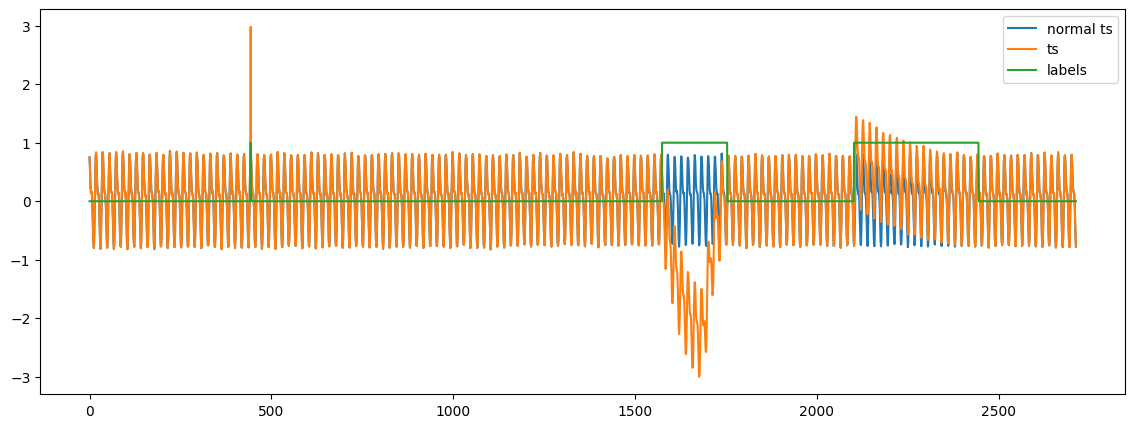

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(dataset[i]["normal_time_series"], label="normal ts")
plt.plot(dataset[i]["time_series"], label="ts")
plt.plot(dataset[i]["labels"], label="labels")
plt.legend()
plt.show()

In [79]:
dataset[i]["attribute"]

{'seasonal': 'sin periodic fluctuation',
 'trend': 'keep steady',
 'frequency': 'high frequency',
 'noise': 'almost no noise',
 'anomalies': {'0_outlier': (443, 444),
  '1_wide downward spike': (1574, 1754),
  '2_rapid rise followed by slow decline': (2102, 2445)},
 'full_attribute_pool': {'seasonal': {'type': 'sin periodic fluctuation',
   'amplitude': 3.872032737708827,
   'detail': 'Time series shows sin periodic fluctuation: Periodic fluctuation with amplitude 3.9, from point 0 to point 2713.',
   'segments': [{'amplitude': 3.87,
     'position_start': 0,
     'position_end': 2713,
     'description': 'Periodic fluctuation with amplitude 3.9, from point 0 to point 2713'}]},
  'trend': {'type': 'keep steady',
   'start': 6.66,
   'amplitude': 1.5965832565517455,
   'detail': 'From the perspective of the slope, the overall trend is steady. The value of time series starts from around 6.66 and ends at around 3.01, with an overall amplitude of -3.65. ',
   'trend_list': [('keep steady',

In [ ]:
labels = sample['labels']  # предположительно (seq_len, num_features)
print(labels.shape)

# Проверьте, есть ли повторяющиеся паттерны длины patch_size
patch_size = 16
for c in range(num_features):
    channel_labels = labels[:, c]
    for p in range(0, len(channel_labels), patch_size):
        patch_labels = channel_labels[p:p+patch_size]
        # Если все значения в патче одинаковые — это признак "развернутых" token-level меток
        print(f"Patch {p//patch_size}: unique values = {torch.unique(patch_labels)}")

**Чекпоинты:**

In [1]:
!pip install -U "huggingface_hub[cli]"

  Using cached huggingface_hub-1.10.2-py3-none-any.whl.metadata (14 kB)
Using cached huggingface_hub-1.10.2-py3-none-any.whl (642 kB)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
docling 2.43.0 requires accelerate<2,>=1.0.0, which is not installed.
docling 2.43.0 requires lxml<6.0.0,>=4.0.0, which is not installed.
docling 2.43.0 requires pydantic<3.0.0,>=2.0.0, which is not installed.
docling 2.43.0 requires pydantic-settings<3.0.0,>=2.3.0, which is not installed.
docling-ibm-models 3.9.0 requires accelerate<2.0.0,>=1.2.1, which is not installed.
docling-ibm-models 3.9.0 requires pydantic<3.0.0,>=2.0.0, which is not installed.
evaluate 0.4.3 requires datasets>=2.0.0, which is not installed.
peft 0.17.0 requires accelerate>=0.21.0, which is not installed.
smolagents 1.20.0 requires python-dotenv, which is not installed.
docling 2.43.0 requires huggingface_hub<1,>=0.23, but you have huggingface-hub 1.10.2 which is incompatible.
docling 2.43.0 requires pillow<12.0.0,>=10.0.0, but you have pi

In [3]:
import os
from huggingface_hub import hf_hub_download

filepath_uni = hf_hub_download(
    repo_id="thu-sail-lab/Time-RCD",
    filename="Time-RCD/best_model/pretrain_checkpoint_best_uni.pth",
    local_dir=".",
    local_dir_use_symlinks=False  # Важно для Windows
)

filepath_multi = hf_hub_download(
    repo_id="thu-sail-lab/Time-RCD",
    filename="Time-RCD/best_model/pretrain_checkpoint_best_multi.pth",
    local_dir=".",
    local_dir_use_symlinks=False  # Важно для Windows
)

C:\Users\Oleg\miniconda3\envs\diplom\lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


best_model/pretrain_checkpoint_best_uni.(…):   0%|          | 0.00/445M [00:00<?, ?B/s]

best_model/pretrain_checkpoint_best_mult(…):   0%|          | 0.00/445M [00:00<?, ?B/s]

# Testing